Youtube Data Analysis

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [10]:
comments = pd.read_csv(
    "/Users/priscilasalgado/Desktop/Proyect 1/UScomments.csv",
    engine="python",
    on_bad_lines="skip"
)

In [11]:
comments.head(10)

,video_id,comment_text,likes,replies
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0
4,XpVt6Z1Gjjo,trending 😉,3,0
5,XpVt6Z1Gjjo,#1 on trending AYYEEEEE,3,0
6,XpVt6Z1Gjjo,The end though 😭👍🏻❤️,4,0
7,XpVt6Z1Gjjo,#1 trending!!!!!!!!!,3,0
8,XpVt6Z1Gjjo,Happy one year vlogaversary,3,0
9,XpVt6Z1Gjjo,You and your shit brother may have single hand...,0,0


In [12]:
type(comments)

pandas.core.frame.DataFrame

In [13]:
comments.isnull().sum()

video_id         0
comment_text    26
likes            0
replies          0
dtype: int64

In [14]:
comments.dropna(inplace= True)

In [15]:
comments.isnull().sum()

video_id        0
comment_text    0
likes           0
replies         0
dtype: int64

In [16]:
import nltk 

In [17]:
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/priscilasalgado/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [18]:
 from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [19]:
sia = SentimentIntensityAnalyzer()

In [20]:
sia.polarity_scores("MY FAN , attendance")['compound']

0.4648

In [21]:
sentimen_scores = []

for comment in comments["comment_text"]:
    score = sia.polarity_scores(str(comment))['compound']
    sentimen_scores.append(score)

In [22]:
sample_df = comments[0:10000]

In [24]:
comments['polarity'] = comments['comment_text'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [25]:
comments.head(5)

,video_id,comment_text,likes,replies,polarity
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0,0.0000
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0,0.0000
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0,0.0000
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0,0.4648
4,XpVt6Z1Gjjo,trending 😉,3,0,0.0000


3. Wordcloud Analysis

In [27]:
filter_pos = (comments['polarity'] >= 0.8) & (comments['polarity'] <= 1.0)

In [28]:
comments_positive = comments[filter_pos] 

In [29]:
comments_positive.shape

(64309, 5)

In [30]:
filter_neg = (comments['polarity'] >= -1.0) & (comments['polarity'] <= -0.8)

In [32]:
comments_negative = comments[filter_neg]

In [33]:
comments_negative.shape

(16148, 5)

In [34]:
! pip install wordcloud

In [37]:
comments_positive['comment_text']

24        I love Logan and Jake so much and thay are so ...
27        if you get allot of diss likes do you get on t...
29        I love you so much I love to meet you But I li...
45        This looks like a great video, but after you a...
57        Congrats Logan love u so much someday I would ...
                                ...                        
691307    Fabulous video, just so wonderful live.It's so...
691317    I love each and every version of this song. LP...
691319    Absolutely fabulous ! LP has the genius to ren...
691340                      Beautiful LP! You are gorgeous!
691351        No comments!  Enjoy!  Thanks!  Nice  weekend!
Name: comment_text, Length: 64309, dtype: object

In [40]:
total_positive_comments = ' '.join(comments_positive['comment_text'])

In [41]:
total_positive_comments[0:1000]

"I love Logan and Jake so much and thay are so amazing and I look up to them so much 😍💋💙👍 if you get allot of diss likes do you get on the top comments? lets see diss like this please I love you so much I love to meet you But I live in Israel You really inspire me I really like your channel Keep doing what you do\\nBecause everyone loves it and will be Unique and Pashan will be creative and I hope you will see it bye This looks like a great video, but after you are done would you be kind enough to check out my new YouTube channel and give me some feedback? Maybe even subscribing? :) Congrats Logan love u so much someday I would love to meet u #1 fan of the logang ❤️ Well done I LOVE! You so much :D I am very happy for this man and we need to spread more love. United we stand, divided we fall. And this could in all honestly become a good thing for you. You sit on a platform where you could really educate people especially when so many of your fans seem to think it's okay to be said. Rea

In [42]:
set(STOPWORDS)

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

In [35]:
from wordcloud import WordCloud , STOPWORDS

In [43]:
wordcloud_positive = WordCloud(stopwords = set(STOPWORDS)).generate(total_positive_comments)

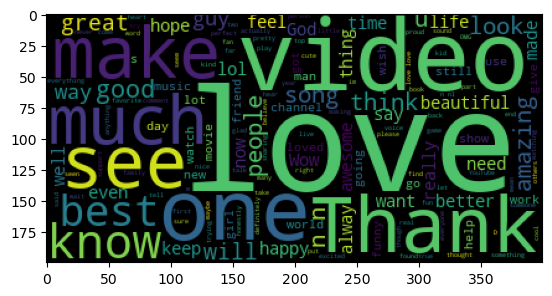

In [45]:
plt.imshow(wordcloud_positive)

In [46]:
total_negative_comments = ' '.join(comments_negative['comment_text'])

In [47]:
wordcloud_negative = WordCloud(stopwords = set(STOPWORDS)).generate(total_negative_comments)

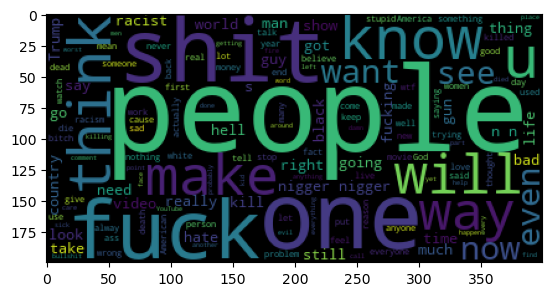

In [48]:
plt.imshow(wordcloud_negative)

Emoji Analysis

In [49]:
! pip install emoji==2.14.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 3.7 MB/s  0:00:0036m-:--:--


In [50]:
import emoji

In [53]:
emoji.__version__

'2.14.1'

In [65]:
comments.head()

,video_id,comment_text,likes,replies,polarity
0,XpVt6Z1Gjjo,Logan Paul it's yo big day ‼️‼️‼️,4,0,0.0000
1,XpVt6Z1Gjjo,I've been following you from the start of your...,3,0,0.0000
2,XpVt6Z1Gjjo,Say hi to Kong and maverick for me,3,0,0.0000
3,XpVt6Z1Gjjo,MY FAN . attendance,3,0,0.4648
4,XpVt6Z1Gjjo,trending 😉,3,0,0.0000


In [69]:
emojis_info = emoji.emoji_list('trending 😉')

In [82]:
comments['comment_text']

0                         Logan Paul it's yo big day ‼️‼️‼️
1         I've been following you from the start of your...
2                        Say hi to Kong and maverick for me
3                                       MY FAN . attendance
4                                                trending 😉
                                ...                        
691390                                               Лучшая
691391    qu'est ce que j'aimerais que tu viennes à Roan...
691392                            Ven a mexico! 😍 te amo LP
691393                                      Islığı yeter...
691394    Kocham tą piosenkę😍❤❤❤byłam zakochana po uszy ...
Name: comment_text, Length: 691369, dtype: object

In [91]:
all_emojis_found = []

for comment in comments['comment_text']:
    emojis_info = emoji.emoji_list(str(comment))
    emojis_found = [item['emoji'] for item in emojis_info]
    all_emojis_found.extend(emojis_found)

In [92]:
all_emojis_found[1:10]

['‼️', '‼️', '😉', '😭', '👍🏻', '❤️', '😍', '💋', '💙']

In [93]:
len(all_emojis_found)

288886

In [94]:
from collections import Counter

In [96]:
emojis_count_list_top10 = Counter(all_emojis_found).most_common(10)

In [97]:
emojis_count_list_top10

[('😂', 36998),
 ('😍', 33453),
 ('❤️', 16911),
 ('❤', 14167),
 ('🔥', 8694),
 ('😭', 8398),
 ('😘', 5545),
 ('💖', 5362),
 ('💕', 5147),
 ('👍', 4251)]

In [102]:
emojis = [emoji for emoji , count in emojis_count_list_top10]
counts = [count for emoji , count in emojis_count_list_top10]

In [103]:
emojis

['😂', '😍', '❤️', '❤', '🔥', '😭', '😘', '💖', '💕', '👍']

In [104]:
counts

[36998, 33453, 16911, 14167, 8694, 8398, 5545, 5362, 5147, 4251]

In [106]:
!pip install plotly

In [107]:
import plotly.graph_objs as go
from plotly.offline import iplot

In [114]:
trace = go.Bar(x = emojis , y = counts)

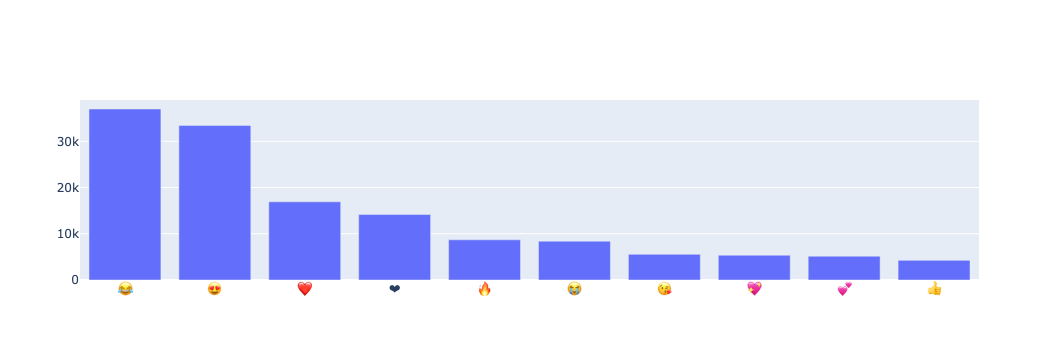

In [115]:
iplot([trace])

In [116]:
import os

In [119]:
files = os.listdir('/Users/priscilasalgado/Desktop/Proyect 1/additional_data')

In [120]:
files

['IN_category_id.json',
 'MXvideos.csv',
 'RU_category_id.json',
 'JP_category_id.json',
 'FR_category_id.json',
 'INvideos.csv',
 'GB_category_id.json',
 'DEvideos.csv',
 'JPvideos.csv',
 'KR_category_id.json',
 'KRvideos.csv',
 'CAvideos.csv',
 'MX_category_id.json',
 'RUvideos.csv',
 'FRvideos.csv',
 'CA_category_id.json',
 'US_category_id.json',
 'DE_category_id.json',
 'USvideos.csv',
 'GBvideos.csv']

In [129]:
files_csv = [file for file in files if ".csv" in file]

In [128]:
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [133]:
full_df = pd.DataFrame()
path = r'/Users/priscilasalgado/Desktop/Proyect 1/additional_data'

for file in files_csv:
    current_df = pd.read_csv(
        path + '/' + file,
        encoding='iso-8859-1',
        on_bad_lines='skip'
    )
    full_df = pd.concat([full_df, current_df], ignore_index=True)
 

In [134]:
full_df.shape

(375942, 16)

In [136]:
full_df[full_df.duplicated()].shape

(36417, 16)

In [137]:
full_df = full_df.drop_duplicates()

In [138]:
full_df.shape

(339525, 16)

In [139]:
full_df[0:1000].to_csv(r'/Users/priscilasalgado/Desktop/Proyect 1/youtube_sample.csv', index = False)

In [140]:
from sqlalchemy import create_engine

In [143]:
engine = create_engine(r'sqlite:////Users/priscilasalgado/Desktop/Proyect 1/youtube_sample.sqlite')

In [146]:
full_df[0:1000].to_sql('Users', con=engine , if_exists = 'append')

1000

In [148]:
 full_df.head(5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,SbOwzAl9ZfQ,17.14.11,CapÃ­tulo 12 | MasterChef 2017,MasterChef 2017,24,2017-11-13T06:06:22.000Z,"MasterChef Junior 2017|""TV Azteca""|""recetas""|""...",310130,4182,361,1836,https://i.ytimg.com/vi/SbOwzAl9ZfQ/default.jpg,False,False,False,Disfruta la presencia del Chef Torreblanca en ...
1,klOV6Xh-DnI,17.14.11,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...,Micky Contreras Martinez,22,2017-11-13T05:11:58.000Z,La Voz Mexico 7,104972,271,174,369,https://i.ytimg.com/vi/klOV6Xh-DnI/default.jpg,False,False,False,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...
2,6L2ZF7Qzsbk,17.14.11,LOUIS CKAGÃ - EL PULSO DE LA REPÃBLICA,El Pulso De La RepÃºblica,25,2017-11-13T17:00:02.000Z,"Chumel Torres|""El Pulso de la Republica""|""noti...",136064,10105,266,607,https://i.ytimg.com/vi/6L2ZF7Qzsbk/default.jpg,False,False,False,La canciÃ³n del principio se llama âEste esp...
3,hcY52MFWMDM,17.14.11,Sismo de 6.7 sacude Costa Rica 12 Noviembre 2017,Casanare,25,2017-11-13T03:47:10.000Z,"temblor|""costa rica""|""sismo en costa rica""",96153,378,171,208,https://i.ytimg.com/vi/hcY52MFWMDM/default.jpg,False,False,False,El video es de un Walmart en el pais centroame...
4,_OXDcGPVAa4,17.14.11,DOG HACKS | MUSAS LESSLIE LOS POLINESIOS,Musas,26,2017-11-13T19:17:48.000Z,"MUSAS|""lesslie""|""karen""|""hacks""|""perros""|""dogs...",499965,57781,681,7428,https://i.ytimg.com/vi/_OXDcGPVAa4/default.jpg,False,False,False,MI HERMANO NARRA MI RUTINA DE MAQUILLAJE\nhttp...


In [149]:
full_df['category_id'].unique()

array([24, 22, 25, 26, 10, 23, 17,  2,  1, 29, 27, 28, 20, 15, 19, 43, 30,
       44])

In [152]:
json_df = pd.read_json(r'/Users/priscilasalgado/Desktop/Proyect 1/additional_data/US_category_id.json')

In [153]:
json_df['items'][0]

{'kind': 'youtube#videoCategory',
 'etag': '"m2yskBQFythfE4irbTIeOgYYfBU/Xy1mB4_yLrHy_BmKmPBggty2mZQ"',
 'id': '1',
 'snippet': {'channelId': 'UCBR8-60-B28hp2BmDPdntcQ',
  'title': 'Film & Animation',
  'assignable': True}}

In [155]:
cat_dict = {}

for item in json_df['items'].values:
    cat_dict[int(item['id'])]= [item['snippet']['title']]

In [156]:
cat_dict

{1: ['Film & Animation'],
 2: ['Autos & Vehicles'],
 10: ['Music'],
 15: ['Pets & Animals'],
 17: ['Sports'],
 18: ['Short Movies'],
 19: ['Travel & Events'],
 20: ['Gaming'],
 21: ['Videoblogging'],
 22: ['People & Blogs'],
 23: ['Comedy'],
 24: ['Entertainment'],
 25: ['News & Politics'],
 26: ['Howto & Style'],
 27: ['Education'],
 28: ['Science & Technology'],
 29: ['Nonprofits & Activism'],
 30: ['Movies'],
 31: ['Anime/Animation'],
 32: ['Action/Adventure'],
 33: ['Classics'],
 34: ['Comedy'],
 35: ['Documentary'],
 36: ['Drama'],
 37: ['Family'],
 38: ['Foreign'],
 39: ['Horror'],
 40: ['Sci-Fi/Fantasy'],
 41: ['Thriller'],
 42: ['Shorts'],
 43: ['Shows'],
 44: ['Trailers']}

In [158]:
full_df['category_name'] = full_df['category_id'].map(cat_dict)

In [163]:
full_df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,SbOwzAl9ZfQ,17.14.11,CapÃ­tulo 12 | MasterChef 2017,MasterChef 2017,24,2017-11-13T06:06:22.000Z,"MasterChef Junior 2017|""TV Azteca""|""recetas""|""...",310130,4182,361,1836,https://i.ytimg.com/vi/SbOwzAl9ZfQ/default.jpg,False,False,False,Disfruta la presencia del Chef Torreblanca en ...,[Entertainment]
1,klOV6Xh-DnI,17.14.11,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...,Micky Contreras Martinez,22,2017-11-13T05:11:58.000Z,La Voz Mexico 7,104972,271,174,369,https://i.ytimg.com/vi/klOV6Xh-DnI/default.jpg,False,False,False,ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUN...,[People & Blogs]
2,6L2ZF7Qzsbk,17.14.11,LOUIS CKAGÃ - EL PULSO DE LA REPÃBLICA,El Pulso De La RepÃºblica,25,2017-11-13T17:00:02.000Z,"Chumel Torres|""El Pulso de la Republica""|""noti...",136064,10105,266,607,https://i.ytimg.com/vi/6L2ZF7Qzsbk/default.jpg,False,False,False,La canciÃ³n del principio se llama âEste esp...,[News & Politics]
3,hcY52MFWMDM,17.14.11,Sismo de 6.7 sacude Costa Rica 12 Noviembre 2017,Casanare,25,2017-11-13T03:47:10.000Z,"temblor|""costa rica""|""sismo en costa rica""",96153,378,171,208,https://i.ytimg.com/vi/hcY52MFWMDM/default.jpg,False,False,False,El video es de un Walmart en el pais centroame...,[News & Politics]
4,_OXDcGPVAa4,17.14.11,DOG HACKS | MUSAS LESSLIE LOS POLINESIOS,Musas,26,2017-11-13T19:17:48.000Z,"MUSAS|""lesslie""|""karen""|""hacks""|""perros""|""dogs...",499965,57781,681,7428,https://i.ytimg.com/vi/_OXDcGPVAa4/default.jpg,False,False,False,MI HERMANO NARRA MI RUTINA DE MAQUILLAJE\nhttp...,[Howto & Style]


In [167]:
full_df_exploded = full_df.explode('category_name')


In [175]:
full_df['like_rate'] = (full_df['likes']/full_df['views'])*100
full_df['dislike_rate'] = (full_df['dislikes']/full_df['views'])*100
full_df['comment_rate'] =  (full_df['comment_count']/full_df['views'])*100

In [176]:
full_df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description', 'category_name', 'like_rate',
       'dislike_rate', 'comment_rate'],
      dtype='object')

In [177]:
full_df_exploded = full_df.explode('category_name')


In [185]:
order_like = (
    full_df_exploded
    .groupby('category_name')['like_rate']
    .median()
    .sort_values(ascending=False)
    .index
)


In [187]:
order_dislike= (
    full_df_exploded
    .groupby('category_name')['like_rate']
    .median()
    .sort_values(ascending=False)
    .index
)


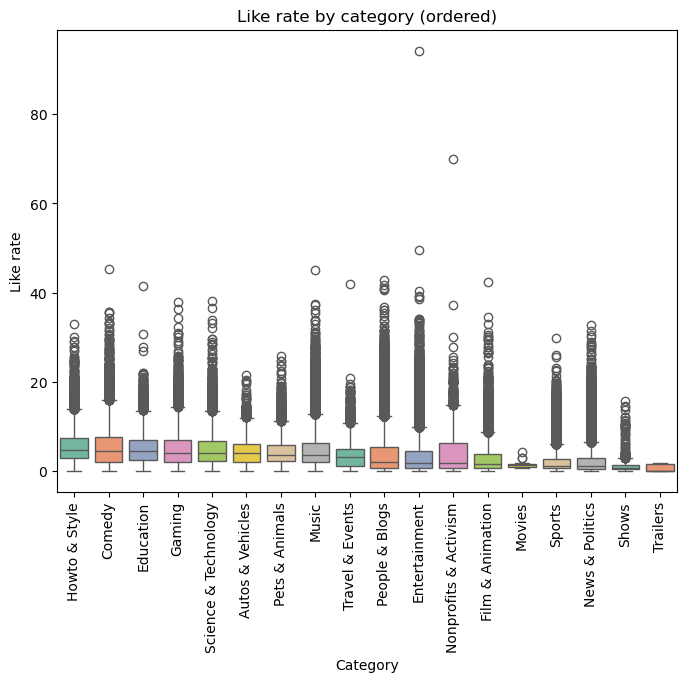

In [189]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='category_name',
    y='like_rate',
    data=full_df_exploded,
    order=order_like,
    palette='Set2'  
)

plt.xticks(rotation=90)
plt.xlabel('Category')
plt.ylabel('Like rate')
plt.title('Like rate by category (ordered)')
plt.show()


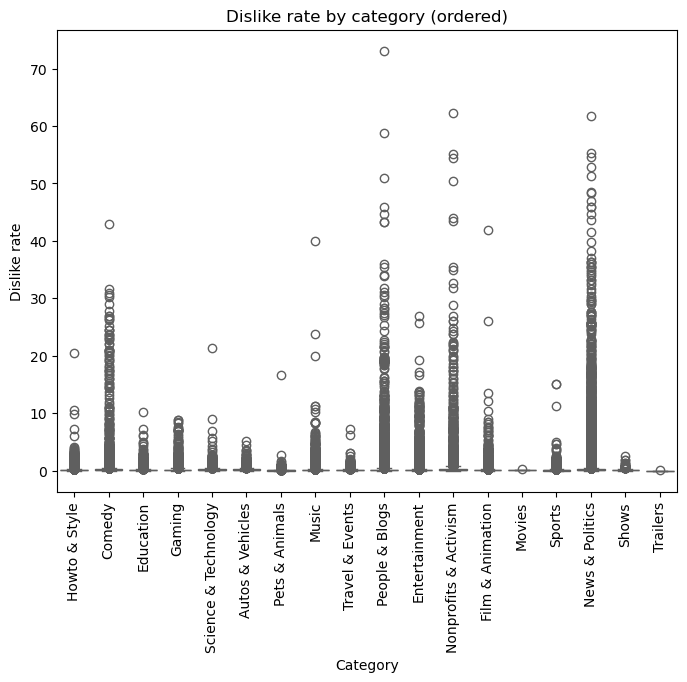

In [190]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='category_name',
    y='dislike_rate',
    data=full_df_exploded,
    order=order_dislike,
    palette='Set3'  
)

plt.xticks(rotation=90)
plt.xlabel('Category')
plt.ylabel('Dislike rate')
plt.title('Dislike rate by category (ordered)')
plt.show()

<Axes: xlabel='views', ylabel='likes'>

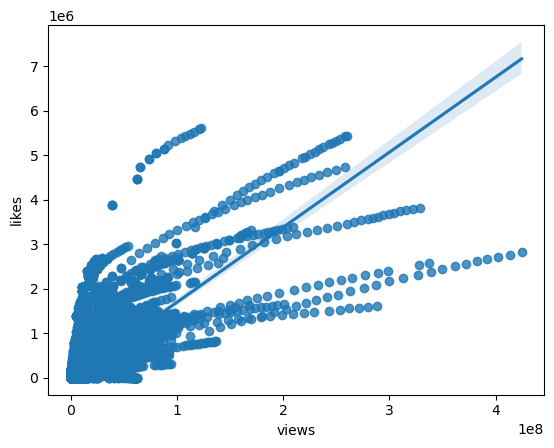

In [191]:
sns.regplot(x = 'views', y = 'likes', data = full_df)

In [192]:
full_df[['views','likes','dislikes']].corr()

,views,likes,dislikes
views,1.000000,0.779531,0.405428
likes,0.779531,1.000000,0.451809
dislikes,0.405428,0.451809,1.000000


<Axes: >

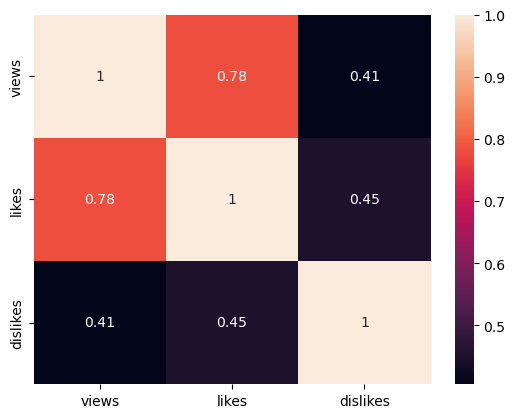

In [194]:
sns.heatmap(full_df[['views','likes','dislikes']].corr(), annot = True)

In [195]:
full_df['channel_title'].value_counts()

channel_title
The Late Show with Stephen Colbert    710
WWE                                   643
Late Night with Seth Meyers           592
TheEllenShow                          555
Jimmy Kimmel Live                     528
                                     ... 
ABIZ ENT BUZZ                           1
JENNYMOMENT                             1
Drache Offiziell                        1
Jules                                   1
The Chainsmokers                        1
Name: count, Length: 37824, dtype: int64

In [199]:
cdf =full_df.groupby(['channel_title']).size().sort_values(ascending=False).reset_index()

In [200]:
cdf

,channel_title,0
0,The Late Show with Stephen Colbert,710
1,WWE,643
2,Late Night with Seth Meyers,592
3,TheEllenShow,555
4,Jimmy Kimmel Live,528
...,...,...
37819,Kd Malts,1
37820,Zedan TV,1
37821,Kc Kelly - Rocketprenuer,1
37822,Kbaby,1


In [219]:
cdf = cdf.rename(columns = {0:'total videos'})

In [218]:
cdf

,channel_title,total videos
0,The Late Show with Stephen Colbert,710
1,WWE,643
2,Late Night with Seth Meyers,592
3,TheEllenShow,555
4,Jimmy Kimmel Live,528
...,...,...
37819,Kd Malts,1
37820,Zedan TV,1
37821,Kc Kelly - Rocketprenuer,1
37822,Kbaby,1


In [204]:
import plotly.express as px

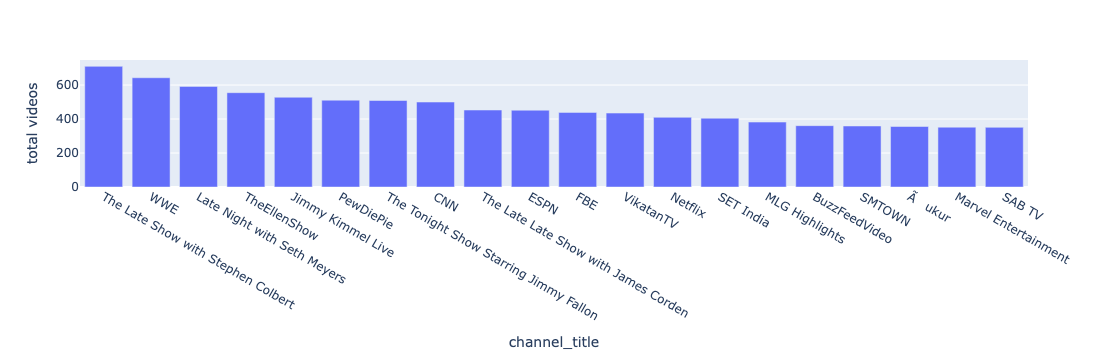

In [220]:
px.bar(data_frame = cdf[0:20] , x = 'channel_title' , y = 'total videos')

In [233]:
full_df['title'][1]

'ALEXA EX-INTEGRANTE DEL GRUPO TIMBIRICHE RENUNCIA A Â¨La Voz Mexico 7Â¨TELEVISA 11/11/2017'

In [222]:
import string

In [223]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [234]:
len([char for char in full_df['title'][1] if char in string.punctuation])

3

In [237]:
sample = full_df[0:10000]

In [235]:
def punc_count(text):
    return len([char for char in text if char in string.punctuation])

In [238]:
sample['count_punc'] = sample['title'].apply(punc_count)

In [240]:
sample['count_punc']

0       1
1       3
2       1
3       1
4       1
       ..
9995    2
9996    3
9997    1
9998    1
9999    0
Name: count_punc, Length: 10000, dtype: int64

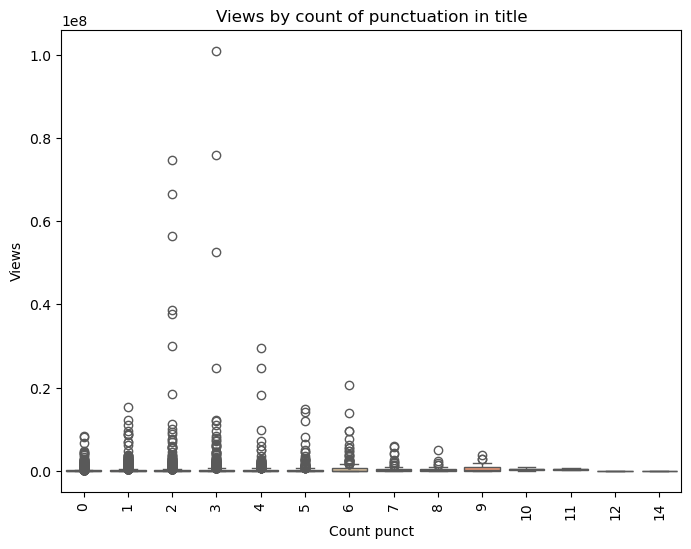

In [243]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x='count_punc',
    y='views',
    data=sample,
    palette='Set2'  
)

plt.xticks(rotation=90)
plt.xlabel('Count punct')
plt.ylabel('Views')
plt.title('Views by count of punctuation in title')
plt.show()